In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

from matplotlib.animation import FuncAnimation, PillowWriter

## Funciones auxiliares

In [2]:
# Algoritmos para la factorización de matrices y sustitución progresiva y regresiva
# ------ Factorización LU ------
def matrix_factorization_nxn(
    diagonal: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior: np.array,  # Vector que contiene los coeficientes de la matriz (diagonal inferior)
):
    """
    Función para realizar la factorización de una matriz tridiagonal A = L*U
    donde L es una matriz triangular inferior con 1's en la diagonal principal y
    U es una matriz triangular superior.
    Parámetros:
    diagonal : np.array
        Vector que contiene los coeficientes de la matriz (diagonal)
    diagonal_superior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal superior)
    diagonal_inferior : np.array
        Vector que contiene los coeficientes de la matriz (diagonal inferior)
    Retorna:
    l_diag : np.array
        Vector que contiene los coeficientes de la matriz L (diagoanl)
    l_diag_inf : np.array
        Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    u_diag_sup : np.array
        Vector que contiene los coeficientes de la matriz U (diagonal)
    """
    l_diag = np.zeros(len(diagonal))
    l_diag_inf = np.zeros(len(diagonal_inferior))
    u_diag_sup = np.zeros(len(diagonal_superior))

    l_diag[0] = diagonal[0]
    l_diag_inf = diagonal_inferior.copy()
    for i in range(0, len(diagonal_superior)):
        u_diag_sup[i] = diagonal_superior[i] / l_diag[i]
        l_diag[i + 1] = diagonal[i + 1] - l_diag_inf[i] * u_diag_sup[i]

    return l_diag, l_diag_inf, u_diag_sup


# ------ Algoritmos para la sustitución progresiva y regresiva ------
# === Sustirución Regresiva ===
# Solución del sistema Ux = z
def sustitucion_regresiva(
    u_diagonal_superior: np.array,  # Vector que contiene los coeficientes de la matriz U (diagonal superior)
    termino_independiente: np.array,  # Vector que contiene los términos independientes
):
    x = np.zeros(len(termino_independiente))
    x[-1] = termino_independiente[-1]
    for i in range(len(termino_independiente) - 2, -1, -1):  # de n-2 hasta 0
        x[i] = termino_independiente[i] - u_diagonal_superior[i] * x[i + 1]

    return x


# === Sustitución Progresiva ===
# Solución del sistema Lz = b
def sustitucion_progresiva(
    l_diagonal: np.array,  # Vector que contiene los coeficientes de la matriz L (diagonal)
    l_diagonal_inferior: np.array,  # Vector que contiene los coeficientes de la matriz L (diagonal inferior)
    termino_independiente: np.array,  # Vector que contiene los términos independientes
):
    z = np.zeros(len(termino_independiente))
    z[0] = termino_independiente[0] / l_diagonal[0]
    for i in range(1, len(termino_independiente)):
        z[i] = (
            termino_independiente[i] - l_diagonal_inferior[i - 1] * z[i - 1]
        ) / l_diagonal[i]

    return z


class Esquema(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def calcular_esquema(self):
        pass


def animar_esquema(esquema, a, b, T, filename="animacion_esquema.gif", fps=30):
    """
    Genera y guarda una animación de la evolución temporal del esquema numérico.

    Parámetros
    ----------
    esquema : objeto de clase EsquemaAdelanteCentrado
        Instancia ya configurada del esquema.
    a, b : float
        Límites espaciales del dominio.
    T : float
        Tiempo total de simulación.
    filename : str
        Nombre del archivo GIF (sin extensión).
    fps : int
        Cuadros por segundo para la animación.
    """
    # === 1. Calcular el esquema ===
    V = esquema.calcular_esquema()

    # === 2. Variables espaciales y temporales ===
    x = np.arange(a + esquema.valor_h, b, esquema.valor_h)
    t = np.arange(0, T + esquema.valor_k, esquema.valor_k)

    # Ajustar longitudes en caso de que difieran
    Nt, Nx = V.shape
    if len(t) > Nt:
        t = t[:Nt]

    # === 3. Crear figura ===
    fig, ax = plt.subplots()
    line, = ax.plot(x, V[0, :], color="blue", lw=2)
    ax.set_xlim(a, b)
    ax.set_ylim(np.min(V) * 1.1, np.max(V) * 1.1)
    ax.set_xlabel("x")
    ax.set_ylabel("u(t,x)")
    ax.set_title("Evolución temporal del esquema")
    ax.grid(True)

    # === 4. Función de actualización ===
    def update(frame):
        line.set_ydata(V[frame, :])
        ax.set_title(f"t = {t[frame]:.3f} s")
        return line,

    # === 5. Crear animación ===
    ani = FuncAnimation(fig, update, frames=Nt, interval=1000/fps, blit=True)

    # === 6. Guardar como GIF ===
    ani.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"✅ Animación guardada como: {filename}")


## Solución del problema

In [3]:
# Variables de la parte espacial
a = -1  # Limite inferior del intervalo a evaluar
b = 1  # Limite superior del intervalo a evaluar

h = [1 / 10, 1 / 20, 1 / 40, 1 / 80, 1 / 160]
i = 0  # Valor de h para escoger

# Variables de la parte temporal
beta = 0.6
T = 1.2  # Limite superior del intervalo temporal

k1 = beta * h[i]
k2 = beta * h[i] ** 2

k = [k1, k2]
j = 0  # Valor de k para escoger

alpha = -1 / 2  # Constante que acompaña a la derivada espacial
cons_matriz = (alpha * k[j]) / (2 * h[i])

print(f"Valor de h: {h[i]}")
print(f"Valor de k: {k[j]}")


Valor de h: 0.1
Valor de k: 0.06


In [4]:
# Definición de la solución del PVI
def solucion(t, x):
    fun = (1 - 1 / 2 * t) * np.exp(-(x**2))
    return fun

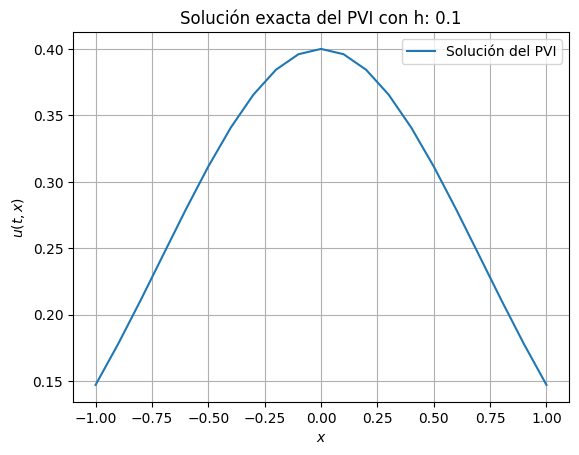

In [5]:
# Visualizar la función
sol = solucion(1.2, np.arange(a, b + h[i], h[i]))

plt.plot(np.arange(a, b + h[i], h[i]), sol, label="Solución del PVI")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$u(t,x)$")
plt.title(f"Solución exacta del PVI con h: {h[i]}")
plt.grid()
plt.show()

## Esquema implícito adelante en tiempo - centrado en espacio

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m+1}^{n+1} - V_{m-1}^{n+1}}{2h} = \frac{f_{m+1}^{n} + f_{m-1}^{n}}{2}$


In [6]:
# Condicion inicial
def condicion_inicial(x):
    fun = np.exp(-(x**2))
    return fun


def f(t, x):
    fun = np.exp(-(x**2)) * (x - 1 / 2 * x * t - 1 / 2)
    return fun

In [7]:
class EsquemaAdelanteCentrado(Esquema):
    def __init__(self, valor_h, valor_k, constante_matriz):
        self.valor_h = valor_h
        self.valor_k = valor_k
        self.constante_matriz = constante_matriz

    def calcular_esquema(self):
        # Cantidad de puntos (asegurar que sean enteros)
        M = int(np.round((b - a) / self.valor_h))
        N = int(np.round(T / self.valor_k))
        
        #print(f"M = {M}, N = {N}")
        #print(f"Dimensión de la matriz: ({N + 1}, {M - 1})")

        # Definición de mallas
        x = np.linspace(a + self.valor_h, b - self.valor_h, M - 1)
        x_aux = np.linspace(a, b, M + 1)
        t = np.linspace(0, T, N + 1)
        
        #print(f"x.shape = {x.shape}, x_aux.shape = {x_aux.shape}, t.shape = {t.shape}")

        # Matriz tridiagonal
        n_interior = M - 1
        diag = np.ones(n_interior)
        diag_inf = -self.constante_matriz * np.ones(n_interior - 1)
        diag_sup = self.constante_matriz * np.ones(n_interior - 1)

        # Factorización
        diag_L, diag_inf_L, diag_sup_U = matrix_factorization_nxn(
            diagonal=diag,
            diagonal_superior=diag_sup,
            diagonal_inferior=diag_inf
        )

        # Matriz solución
        V = np.zeros((N + 1, n_interior))

        # Condiciones iniciales
        V[0, :] = condicion_inicial(x)

        # Iteración temporal
        for i in range(1, N + 1):
            # Vector F (término fuente)
            F = np.zeros(n_interior)
            for j in range(n_interior):
                f1 = f(t[i - 1], x_aux[j])
                f2 = f(t[i - 1], x_aux[j + 2])
                F[j] = self.valor_k * (f1 + f2) / 2

            # Condiciones de frontera
            F[0] += self.constante_matriz * solucion(t[i], a)
            F[-1] -= self.constante_matriz * solucion(t[i], b)

            # Sistema lineal
            V_anterior = V[i - 1, :] + F

            # Resolver
            z = sustitucion_progresiva(diag_L, diag_inf_L, V_anterior)
            V[i, :] = sustitucion_regresiva(diag_sup_U, z)

        return V

In [8]:
# esquema = EsquemaAdelanteCentrado(
#     valor_h=h[i],
#     valor_k=k[j],
#     constante_matriz=cons_matriz,
# )

# name_esquema = f"Esquema adelante tiempo - centrado espacio h={h[i]} - k={k[j]}"
# N = int(T / k[j])

# animar_esquema(
#     esquema=esquema,
#     a=-1,
#     b=1,
#     T=1.2,
#     filename=name_esquema + ".gif",
#     fps=20
# )

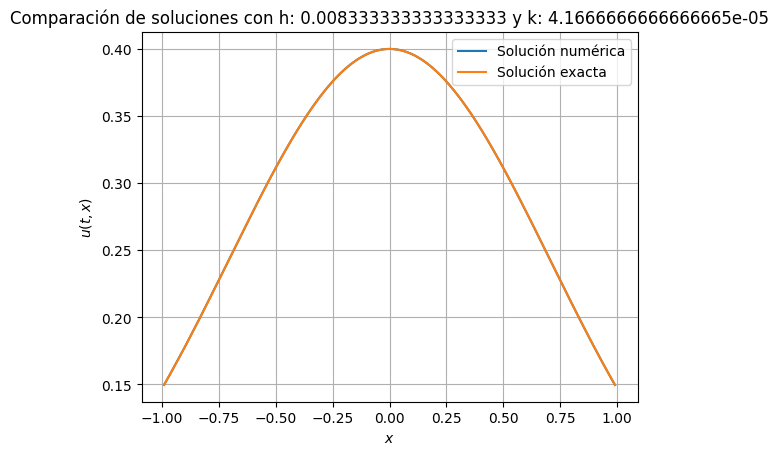

In [9]:
h = 1/120
beta = 0.6
k = beta * h**2
cons_matriz = (alpha * k) / (2 * h)

esquema = EsquemaAdelanteCentrado(
    valor_h=h,
    valor_k=k,
    constante_matriz=cons_matriz,
).calcular_esquema()

x = np.arange(a + h, b, h)

plt.plot(x, esquema[-1, :], label="Solución numérica")
plt.plot(x, solucion(T, x), label="Solución exacta")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$u(t,x)$")
plt.title(f"Comparación de soluciones con h: {h} y k: {k}")
plt.grid()
plt.show()

# Error

SOLUCIÓN NUMÉRICA - ESQUEMA FTCS IMPLÍCITO

Parámetros: T = 1.2, β = 0.6
Solución exacta: u(t,x) = (1 - t/2) * exp(-x²)



TABLA 1: k = β*h (relación lineal)
--------------------------------------------------------------------------------
     O(h)       |        Error         		|        Orden        
--------------------------------------------------------------------------------
1/10 		|   3.4165880007e-02   		|          -          
1/20 		|   1.5936273971e-02   		|       1.100242      
1/40 		|   7.6849854168e-03   		|       1.052200      
1/80 		|   3.7725494229e-03   		|       1.026503      
1/160 		|   1.8689305846e-03   		|       1.013327      


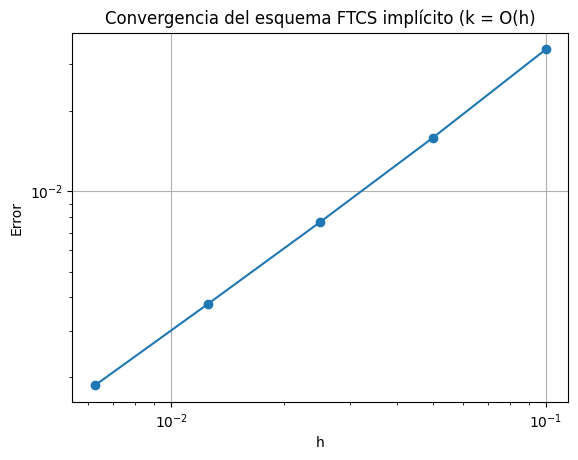

In [10]:
print("=" * 80)
print("SOLUCIÓN NUMÉRICA - ESQUEMA FTCS IMPLÍCITO")
print("=" * 80)
print(f"\nParámetros: T = {T}, β = {beta}")
print("Solución exacta: u(t,x) = (1 - t/2) * exp(-x²)")
print("\n" + "=" * 80)

h_values_linear = [1 / 10, 1 / 20, 1 / 40, 1 / 80, 1 / 160]
h_values_text = ["1/10", "1/20", "1/40", "1/80", "1/160"]
errors_linear = []


def error(h, u_numeric, u_exact):
    return np.sqrt(h * np.sum(np.abs(u_exact - u_numeric) ** 2))


def compute_order(error1, error2, h1, h2):
    """Compute convergence order"""
    if error1 == 0 or error2 == 0:
        return 0
    return np.log(error1 / error2) / np.log(h1/h2)


# Table 1: k = O(h) - Linear relationship
print("\n\nTABLA 1: k = β*h (relación lineal)")
print("-" * 80)
print(f"{'O(h)':^15} | {'Error':^20} \t\t| {'Orden':^20}")
print("-" * 80)

for i, h in enumerate(h_values_linear):
    k = beta * h
    x = np.arange(a, b, h)
    esquema = EsquemaAdelanteCentrado(
        valor_h=h,
        valor_k=k,
        constante_matriz=(alpha * k) / (2 * h),
    )
    error_tn = error(h, esquema.calcular_esquema()[-1, :], solucion(T, x[0:-1]))
    errors_linear.append(error_tn)

    if i == 0:
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {'-':^20}")
    else:
        order = compute_order(errors_linear[i-1], errors_linear[i], h_values_linear[i-1], h_values_linear[i])
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {order:^20.6f}")

plt.plot(h_values_linear, errors_linear, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('h')
plt.ylabel('Error')
plt.title('Convergencia del esquema FTCS implícito (k = O(h)')
plt.grid()
plt.show()

In [11]:
# Table 2: k = O(h^2) - Quadratic relationship
print("\n\nTABLA 2: k = β*h² (relación cuadrática)")
print("-" * 80)
print(f"{'O(h²)':^15} | {'Error':^20} \t\t| {'Orden':^20}")
print("-" * 80)

errors_linear = []

for i, h in enumerate(h_values_linear):
    x = np.arange(a + h, b, h)
    k = beta * h**2
    esquema = EsquemaAdelanteCentrado(
        valor_h=h,
        valor_k=k,
        constante_matriz=(alpha * k) / (2 * h),
    )
    error_tn = error(h, esquema.calcular_esquema()[-1, :], solucion(T, x))
    errors_linear.append(error_tn)

    if i == 0:
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {'-':^20}")
    else:
        order = compute_order(errors_linear[i-1], errors_linear[i], h_values_linear[i-1], h_values_linear[i])
        print(f"{h_values_text[i]} \t\t| {error_tn:^20.10e} \t\t| {order:^20.6f}")



TABLA 2: k = β*h² (relación cuadrática)
--------------------------------------------------------------------------------
     O(h²)      |        Error         		|        Orden        
--------------------------------------------------------------------------------
1/10 		|   5.4780312008e-03   		|          -          
1/20 		|   1.3707529600e-03   		|       1.998689      
1/40 		|   3.4276836547e-04   		|       1.999663      
1/80 		|   8.5697171343e-05   		|       1.999914      
1/160 		|   2.1424613284e-05   		|       1.999978      
